# 🚣 Lecture 5 — From Pose Landmarks to a Standardized Rowing Stroke

**Project question:** How can a computer transform a continuous rowing video into separate, comparable strokes?

In the previous notebook, we learned that MediaPipe can represent a person using body landmarks. In this lecture, we move from **pose** to **motion**:

$$
\text{Video}
\rightarrow
\text{Landmarks over time}
\rightarrow
\text{Joint-angle signals}
\rightarrow
\text{Catch and Finish}
\rightarrow
\text{Individual strokes}
\rightarrow
\text{Standardized stroke fingerprints}
$$

## Controlled scope

This lesson intentionally studies a simple and useful experimental setting:

- one rower;
- one indoor rowing machine;
- a fixed camera;
- a side-view recording;
- the whole body remains visible.

> **Scientific boundary:** This notebook measures and compares movement patterns. It does not diagnose injury, predict medical outcomes, or establish an ideal technique from one short video.

## Learning objectives

By the end of the 90-minute session, you should be able to:

1. Explain why a video is a **time series**, not merely a collection of unrelated images.
2. Convert MediaPipe landmarks into knee, hip, elbow, and trunk-angle signals.
3. Explain why pose measurements contain noise and apply Gaussian smoothing.
4. Detect the **Catch** and **Finish** positions automatically.
5. Segment continuous motion into complete rowing strokes.
6. Resample strokes of different durations into a common 100-point representation.
7. Compare one test stroke with a small personal reference profile.


# 0. Preparation

Run the following setup cells. The video is short, but pose extraction may still require one or two minutes.

While the video is processing, consider this question:

> Can the same knee angle occur during both the Drive and the Recovery?  
> If so, what additional information does the computer need?

In [ ]:
!pip install -q mediapipe scipy plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 5.8 MB/s eta 0:00:00


In [ ]:
import os
import json
import math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

from google.colab import files
from IPython.display import Video, display

np.set_printoptions(precision=2, suppress=True)
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
import os
import urllib.request

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "pose_landmarker/pose_landmarker_heavy/float16/1/"
    "pose_landmarker_heavy.task"
)

if not os.path.exists("pose_landmarker.task"):
    urllib.request.urlretrieve(MODEL_URL, "pose_landmarker.task")

print("Model ready:", os.path.exists("pose_landmarker.task"))

Model ready: True


## Upload the rowing video

Upload the supplied `Video.mov` file. The notebook is designed for one visible rower in a fixed side-view clip.

In [ ]:
uploaded = files.upload()

if not uploaded:
    raise ValueError("No video was uploaded. Run the cell again and select Video.mov.")

VIDEO_PATH = next(iter(uploaded))
print("Uploaded:", VIDEO_PATH)
display(Video(VIDEO_PATH, embed=True, width=720))

Saving Video.mov to Video.mov
Uploaded: Video.mov


In [ ]:
cap = cv2.VideoCapture(VIDEO_PATH)

FPS = cap.get(cv2.CAP_PROP_FPS)
FRAME_COUNT = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
WIDTH = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
DURATION = FRAME_COUNT / FPS

cap.release()

print(f"Resolution: {WIDTH} × {HEIGHT}")
print(f"Frames: {FRAME_COUNT}")
print(f"Frames per second: {FPS:.2f}")
print(f"Duration: {DURATION:.2f} seconds")

Resolution: 568 × 320
Frames: 502
Frames per second: 29.97
Duration: 16.75 seconds


# 1. Extract a continuous pose sequence

In the previous notebook, we used MediaPipe's image mode. Here we use **VIDEO mode**.

VIDEO mode is useful because MediaPipe can use temporal tracking between nearby frames. We also set:

```python
num_poses = 1
```

because our controlled video contains only one athlete.

For frame \(i\), the timestamp is approximately:

$$
t_i = \frac{i}{\text{FPS}}
$$

MediaPipe requires that timestamp in milliseconds.

In [ ]:
base_options = python.BaseOptions(model_asset_path="pose_landmarker.task")

video_options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.50,
    min_pose_presence_confidence=0.50,
    min_tracking_confidence=0.50,
)

video_detector = vision.PoseLandmarker.create_from_options(video_options)
print("VIDEO-mode detector created.")

VIDEO-mode detector created.


In [ ]:
def landmark_to_dict(lm):
    return {
        "x": float(lm.x),
        "y": float(lm.y),
        "z": float(lm.z),
        "visibility": float(lm.visibility),
        "presence": float(lm.presence),
    }


def extract_video_landmarks(video_path, detector):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    landmarks_history = []
    frame_index = 0

    while cap.isOpened():
        ok, frame = cap.read()
        if not ok:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

        timestamp_ms = int((frame_index / fps) * 1000)
        result = detector.detect_for_video(mp_image, timestamp_ms)

        if result.pose_landmarks:
            frame_landmarks = [
                landmark_to_dict(lm)
                for lm in result.pose_landmarks[0]
            ]
        else:
            frame_landmarks = None

        landmarks_history.append(frame_landmarks)

        if frame_index % 50 == 0:
            print(f"Processed frame {frame_index}/{total_frames}")

        frame_index += 1

    cap.release()
    return landmarks_history, fps


video_landmarks, FPS = extract_video_landmarks(VIDEO_PATH, video_detector)

detected_frames = sum(frame is not None for frame in video_landmarks)
print("\nPose extraction complete.")
print(f"Detected frames: {detected_frames}/{len(video_landmarks)}")
print(f"Detection coverage: {100 * detected_frames / len(video_landmarks):.1f}%")

Processed frame 0/502
Processed frame 50/502
Processed frame 100/502
Processed frame 150/502
Processed frame 200/502
Processed frame 250/502
Processed frame 300/502
Processed frame 350/502
Processed frame 400/502
Processed frame 450/502
Processed frame 500/502

Pose extraction complete.
Detected frames: 502/502
Detection coverage: 100.0%


In [ ]:
# Save a cache so that pose extraction does not need to be repeated.
with open("lecture5_landmarks.json", "w") as f:
    json.dump({"fps": FPS, "landmarks": video_landmarks}, f)

print("Saved lecture5_landmarks.json")

Saved lecture5_landmarks.json


## Visual checkpoint: sampled skeletons

The following helper draws a small subset of body connections. We use it only to verify that the tracked skeleton follows the rower across time.

## Some thoughts from Hagan:

* We need also include the neck angle extractions (keypoint 0 perpendicular to 11-12 shoulder line) -> Phase 2 improvement

* And the hand need to flat to arm levels, we need another 4 pairs: left (14, 16) (16, line perpendicular to (20, 18)); right (13, 15), (15, line perpendicular to (17 ,19)

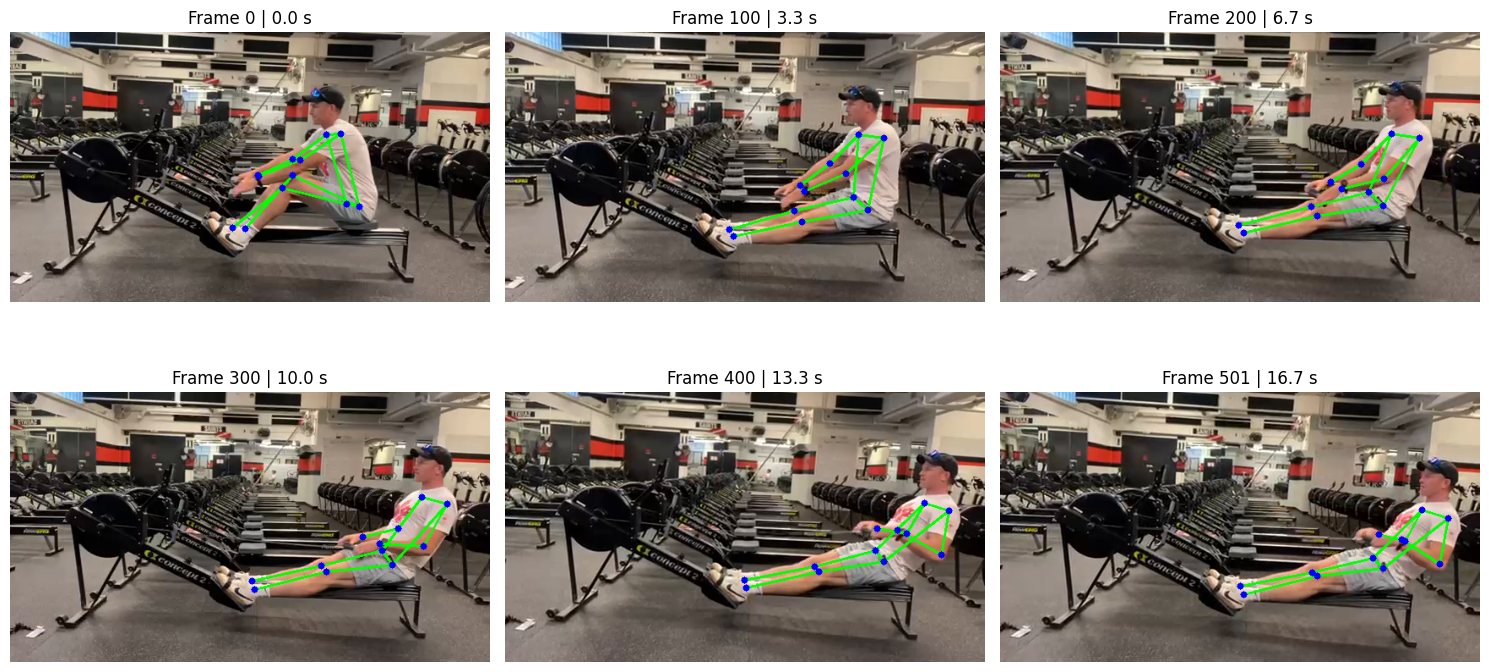

In [ ]:
BODY_CONNECTIONS = [
    (11, 13), (13, 15),   # left arm
    (12, 14), (14, 16),   # right arm
    (11, 12),             # shoulders
    (11, 23), (12, 24),   # trunk
    (23, 24),             # hips
    (23, 25), (25, 27),   # left leg
    (24, 26), (26, 28),   # right leg
]


def draw_saved_landmarks(frame_bgr, landmarks):
    output = frame_bgr.copy()
    if landmarks is None:
        return output

    h, w = output.shape[:2]

    for start, end in BODY_CONNECTIONS:
        p1 = (int(landmarks[start]["x"] * w), int(landmarks[start]["y"] * h))
        p2 = (int(landmarks[end]["x"] * w), int(landmarks[end]["y"] * h))
        cv2.line(output, p1, p2, (0, 255, 0), 2)

    for index in sorted(set(sum(([a, b] for a, b in BODY_CONNECTIONS), []))):
        p = (int(landmarks[index]["x"] * w), int(landmarks[index]["y"] * h))
        cv2.circle(output, p, 4, (255, 0, 0), -1)

    return cv2.cvtColor(output, cv2.COLOR_BGR2RGB)


sample_frames = np.linspace(0, len(video_landmarks) - 1, 6).astype(int)
cap = cv2.VideoCapture(VIDEO_PATH)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, frame_id in zip(axes.ravel(), sample_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_id))
    ok, frame = cap.read()

    if ok:
        annotated = draw_saved_landmarks(frame, video_landmarks[frame_id])
        ax.imshow(annotated)
        ax.set_title(f"Frame {frame_id} | {frame_id / FPS:.1f} s")

    ax.axis("off")

cap.release()
plt.tight_layout()
plt.show()

## Improvement:

* Wrist angle;
* Neck angle;

# 2. Convert landmarks into biomechanical time series

A row of 33 landmarks is difficult to interpret directly. We therefore create four human-readable signals:

- **Knee angle:** hip → knee → ankle
- **Hip angle:** shoulder → hip → knee
- **Elbow angle:** shoulder → elbow → wrist
- **Trunk lean:** shoulder position relative to a vertical line through the hip

For three points \(A\), \(B\), and \(C\), the angle at \(B\) is calculated from two vectors:

$$
\vec{BA} = A-B,
\qquad
\vec{BC} = C-B
$$

$$
\theta =
\cos^{-1}
\left(
\frac{\vec{BA}\cdot\vec{BC}}
{\|\vec{BA}\|\|\vec{BC}\|}
\right)
$$

Because this lesson uses a controlled side view, we calculate angles in the image's \(x,y\) plane. This is simpler and often more stable than using an uncertain depth estimate.

In [ ]:
LANDMARK_INDEX = {
    "left": {
        "shoulder": 11,
        "elbow": 13,
        "wrist": 15,
        "hip": 23,
        "knee": 25,
        "ankle": 27,
    },
    "right": {
        "shoulder": 12,
        "elbow": 14,
        "wrist": 16,
        "hip": 24,
        "knee": 26,
        "ankle": 28,
    },
}


def mean_side_visibility(landmarks_history, side):
    indices = list(LANDMARK_INDEX[side].values())
    values = []

    for frame in landmarks_history:
        if frame is None:
            continue
        values.extend(frame[i]["visibility"] for i in indices)

    return float(np.mean(values))


left_visibility = mean_side_visibility(video_landmarks, "left")
right_visibility = mean_side_visibility(video_landmarks, "right")
ACTIVE_SIDE = "left" if left_visibility >= right_visibility else "right"

print(f"Mean left-side visibility:  {left_visibility:.3f}")
print(f"Mean right-side visibility: {right_visibility:.3f}")
print("Selected active side:", ACTIVE_SIDE)

Mean left-side visibility:  0.936
Mean right-side visibility: 0.483
Selected active side: left


## In-class checkpoint 1 — Complete the joint-angle function

Replace the `TODO` expressions. The vertex of the angle is point `b`.

$$
\vec{BA} = A-B,
\qquad
\vec{BC} = C-B
$$

$$
\theta =
\cos^{-1}
\left(
\frac{\vec{BA}\cdot\vec{BC}}
{\|\vec{BA}\|\|\vec{BC}\|}
\right)
$$

In [ ]:
def calculate_angle_2d(a, b, c):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    c = np.asarray(c, dtype=float)

    # TODO 1: Create vectors from b toward a and c.
    vector_ba = a - b
    vector_bc = c - b

    denominator = np.linalg.norm(vector_ba) * np.linalg.norm(vector_bc)
    if denominator < 1e-8:
        return np.nan

    # TODO 2: Apply the cosine-angle formula.
    cosine = np.dot(vector_ba, vector_bc) / denominator
    cosine = np.clip(cosine, -1.0, 1.0)

    return float(np.degrees(np.arccos(cosine)))

In [ ]:
# A right angle should be approximately 90 degrees.
test_angle = calculate_angle_2d(
    a=[1, 0],
    b=[0, 0],
    c=[1, 1],
)

print("Test angle:", np.round(test_angle, 3))
assert np.isclose(test_angle, 45.0), "Check the vector and cosine calculations."

Test angle: 45.0


In [ ]:
def trunk_lean_from_vertical(shoulder_xy, hip_xy):
    shoulder_xy = np.asarray(shoulder_xy, dtype=float)
    hip_xy = np.asarray(hip_xy, dtype=float)

    dx = shoulder_xy[0] - hip_xy[0]
    dy = shoulder_xy[1] - hip_xy[1]

    # Image y increases downward. Therefore, -dy represents upward height.
    return float(np.degrees(np.arctan2(dx, -dy)))


def extract_frame_features(frame_id, landmarks, fps, side, min_visibility=0.35):
    base = {
        "frame": frame_id,
        "time_s": frame_id / fps,
        "knee_angle": np.nan,
        "hip_angle": np.nan,
        "elbow_angle": np.nan,
        "trunk_lean": np.nan,
        "pose_quality": 0.0,
    }

    if landmarks is None:
        return base

    ids = LANDMARK_INDEX[side]
    quality = float(np.mean([
        landmarks[index]["visibility"]
        for index in ids.values()
    ]))
    base["pose_quality"] = quality

    if quality < min_visibility:
        return base

    point = {
        name: np.array([
            landmarks[index]["x"],
            landmarks[index]["y"],
        ])
        for name, index in ids.items()
    }

    base["knee_angle"] = calculate_angle_2d(
        point["hip"], point["knee"], point["ankle"]
    )
    base["hip_angle"] = calculate_angle_2d(
        point["shoulder"], point["hip"], point["knee"]
    )
    base["elbow_angle"] = calculate_angle_2d(
        point["shoulder"], point["elbow"], point["wrist"]
    )
    base["trunk_lean"] = trunk_lean_from_vertical(
        point["shoulder"], point["hip"]
    )
    # base["wrist_angle"] = calculate_angle_2d(
    #     point["center_palm"], point["wrist"], point["elbow"]
    # )

    return base


feature_rows = [
    extract_frame_features(
        frame_id=i,
        landmarks=landmarks,
        fps=FPS,
        side=ACTIVE_SIDE,
    )
    for i, landmarks in enumerate(video_landmarks)
]

motion = pd.DataFrame(feature_rows)
motion

,frame,time_s,knee_angle,hip_angle,elbow_angle,trunk_lean,pose_quality
0,0,0.000000,77.373585,42.047871,165.008899,-8.376551,0.929683
1,1,0.033363,79.407143,44.890790,164.018521,-9.002865,0.928060
2,2,0.066726,79.061864,45.290414,165.029543,-9.480092,0.924889
3,3,0.100090,77.997526,44.531219,162.575262,-10.514757,0.920807
4,4,0.133453,76.161817,43.774371,162.773227,-10.856883,0.924498
...,...,...,...,...,...,...,...
497,497,16.581517,166.834767,134.969994,28.772275,34.686196,0.955076
498,498,16.614880,166.358244,135.560528,30.627898,35.481637,0.956300
499,499,16.648244,166.135658,135.795458,35.112837,35.821574,0.958670
500,500,16.681607,166.899275,137.165913,37.552402,36.337277,0.959293


In [ ]:
ANGLE_COLUMNS = [
    "knee_angle",
    "hip_angle",
    "elbow_angle",
    "trunk_lean",
]

print("Missing measurements before interpolation:")
display(motion[ANGLE_COLUMNS].isna().sum().to_frame("missing_frames"))

# For this clean, controlled clip, interpolate short gaps.
# In a more serious system, long gaps should cause the stroke to be rejected.
motion[ANGLE_COLUMNS] = (
    motion[ANGLE_COLUMNS]
    .interpolate(limit=5, limit_direction="both")
)

if motion[ANGLE_COLUMNS].isna().any().any():
    raise ValueError(
        "Long pose gaps remain. Inspect the video or reduce the visibility threshold."
    )

print("All required angle signals are ready.")

Missing measurements before interpolation:


,missing_frames
knee_angle,0
hip_angle,0
elbow_angle,0
trunk_lean,0


All required angle signals are ready.


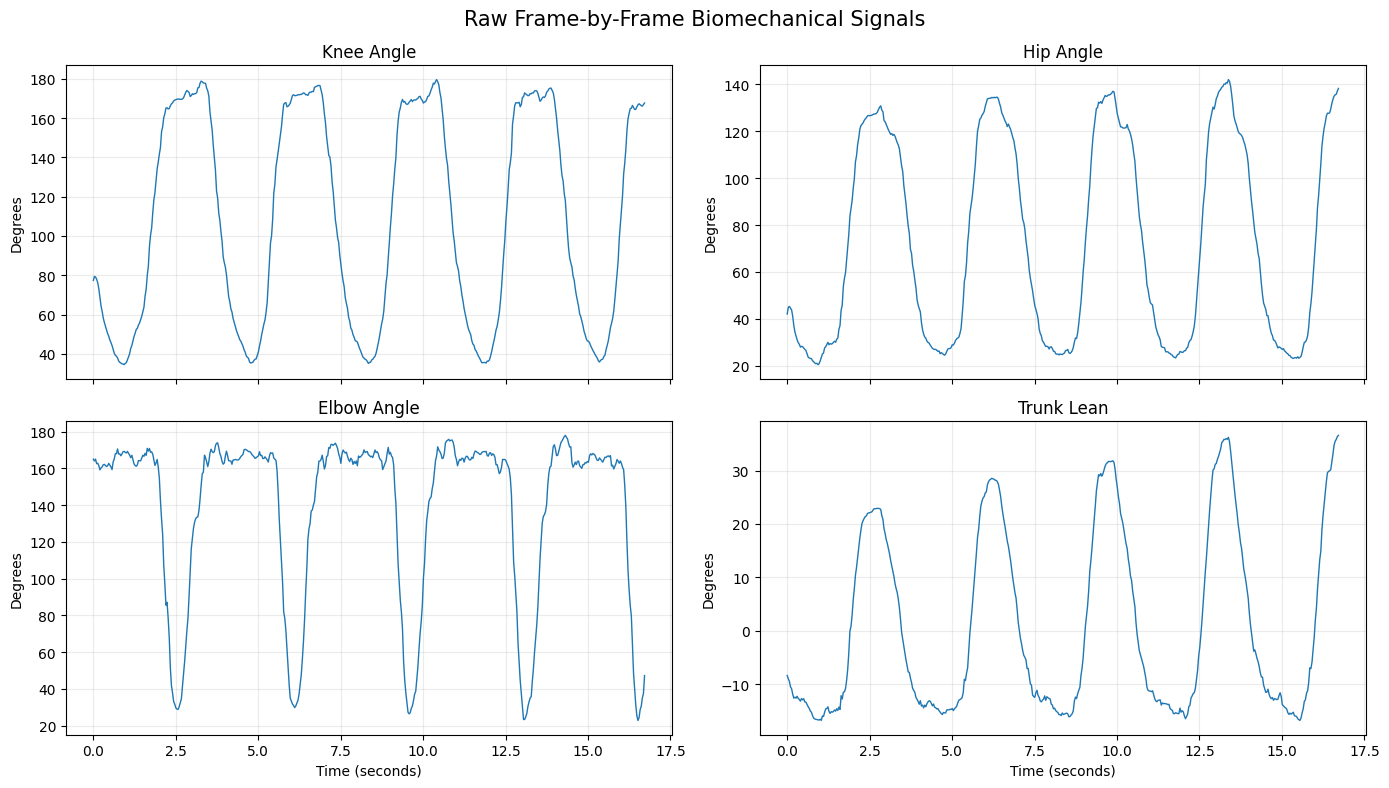

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, column in zip(axes.ravel(), ANGLE_COLUMNS):
    ax.plot(motion["time_s"], motion[column], linewidth=1)
    ax.set_title(column.replace("_", " ").title())
    ax.set_ylabel("Degrees")
    ax.grid(alpha=0.25)

axes[1, 0].set_xlabel("Time (seconds)")
axes[1, 1].set_xlabel("Time (seconds)")
plt.suptitle("Raw Frame-by-Frame Biomechanical Signals", fontsize=15)
plt.tight_layout()
plt.show()

# 3. Denoise the motion and detect repeated strokes

MediaPipe estimates landmarks independently from image evidence, so small frame-to-frame fluctuations are expected. A **Gaussian filter** replaces each measurement with a weighted local average.

A small `sigma` preserves detail but may leave jitter.  
A large `sigma` removes jitter but may also erase real transitions.

We begin with:

```python
sigma = 2
```

At approximately 30 FPS, this represents gentle smoothing over nearby frames.

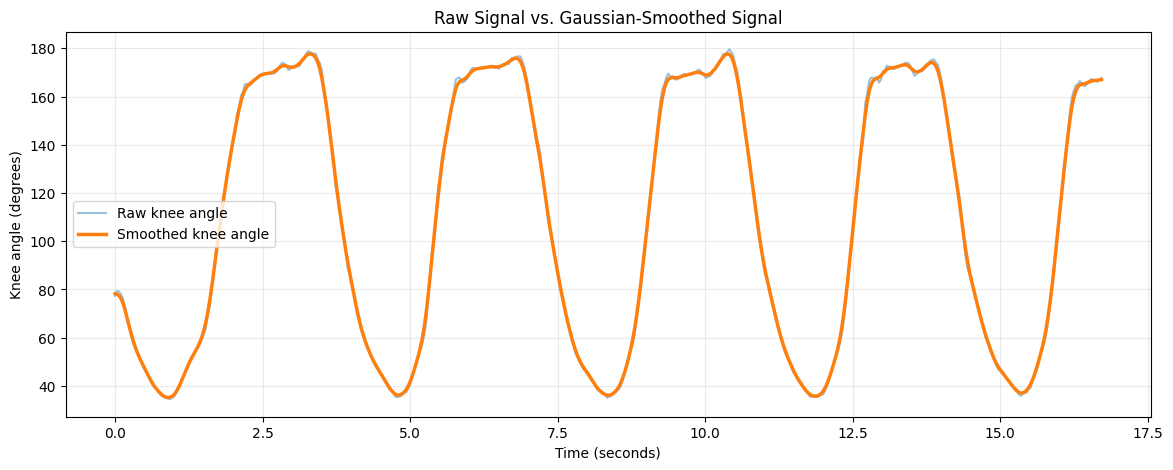

In [ ]:
SMOOTHING_SIGMA = 2.0

for column in ANGLE_COLUMNS:
    motion[f"{column}_smooth"] = gaussian_filter1d(
        motion[column].to_numpy(),
        sigma=SMOOTHING_SIGMA,
    )

plt.figure(figsize=(14, 5))
plt.plot(
    motion["time_s"],
    motion["knee_angle"],
    label="Raw knee angle",
    alpha=0.45,
)
plt.plot(
    motion["time_s"],
    motion["knee_angle_smooth"],
    label="Smoothed knee angle",
    linewidth=2.5,
)
plt.xlabel("Time (seconds)")
plt.ylabel("Knee angle (degrees)")
plt.title("Raw Signal vs. Gaussian-Smoothed Signal")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## Catch and Finish as extrema

In this side-view ergometer video:

- **Catch:** knees are most compressed → knee angle is near a local minimum.
- **Finish:** legs are most extended → knee angle is near a local maximum.

`find_peaks` detects maxima. To detect minima, we search for peaks of the **negative** knee-angle signal.

Two important controls are:

- `distance`: prevents two detections from being unrealistically close;
- `prominence`: ignores small, unimportant fluctuations.

## In-class checkpoint 2 — Detect Finish positions

Complete the first argument of `find_peaks`.

In [ ]:
MIN_STROKE_SECONDS = 2.0
CATCH_PROMINENCE = 15.0

knee_signal = motion["knee_angle_smooth"].to_numpy()

# TODO: find_peaks detects maxima. How do we convert knee-angle valleys
# into peaks without rewriting the algorithm?
catch_frames, catch_properties = find_peaks(
    -knee_signal,
    distance=int(MIN_STROKE_SECONDS * FPS),
    prominence=CATCH_PROMINENCE,
)

print("Detected Catch frames:", catch_frames.tolist())
print("Number of Catch positions:", len(catch_frames))

Detected Catch frames: [27, 144, 251, 355, 460]
Number of Catch positions: 5


In [ ]:
def find_finish_between_catches(knee_signal, catch_frames):
    finish_frames = []

    for start, end in zip(catch_frames[:-1], catch_frames[1:]):
        local_signal = knee_signal[start:end + 1]
        finish = start + int(np.argmax(local_signal))
        finish_frames.append(finish)

    return np.asarray(finish_frames, dtype=int)


finish_frames = find_finish_between_catches(knee_signal, catch_frames)

stroke_rows = []

for stroke_id, (start, finish, end) in enumerate(
    zip(catch_frames[:-1], finish_frames, catch_frames[1:]),
    start=1,
):
    cycle_duration = (end - start) / FPS
    drive_duration = (finish - start) / FPS
    recovery_duration = (end - finish) / FPS
    stroke_rate = 60 / cycle_duration

    stroke_rows.append({
        "stroke": stroke_id,
        "catch_frame": int(start),
        "finish_frame": int(finish),
        "next_catch_frame": int(end),
        "cycle_seconds": cycle_duration,
        "drive_seconds": drive_duration,
        "recovery_seconds": recovery_duration,
        "strokes_per_minute": stroke_rate,
    })

stroke_summary = pd.DataFrame(stroke_rows)
display(stroke_summary.round(2))

,stroke,catch_frame,finish_frame,next_catch_frame,cycle_seconds,drive_seconds,recovery_seconds,strokes_per_minute
0,1,27,99,144,3.90,2.4,1.50,15.37
1,2,144,204,251,3.57,2.0,1.57,16.81
2,3,251,311,355,3.47,2.0,1.47,17.29
3,4,355,415,460,3.50,2.0,1.50,17.13


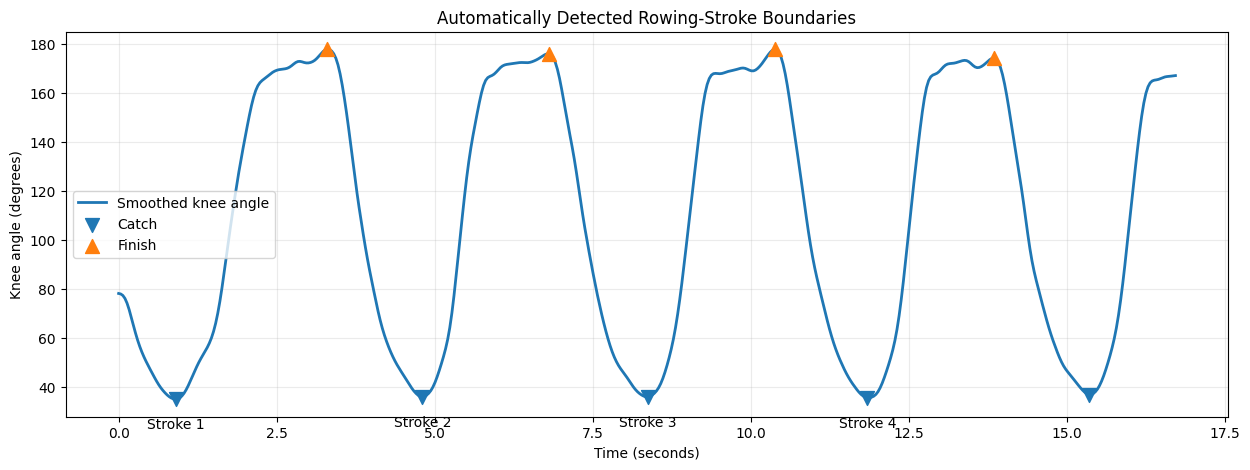

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(
    motion["time_s"],
    knee_signal,
    label="Smoothed knee angle",
    linewidth=2,
)

plt.scatter(
    motion.loc[catch_frames, "time_s"],
    knee_signal[catch_frames],
    marker="v",
    s=100,
    label="Catch",
    zorder=5,
)

plt.scatter(
    motion.loc[finish_frames, "time_s"],
    knee_signal[finish_frames],
    marker="^",
    s=100,
    label="Finish",
    zorder=5,
)

for stroke_id, start in enumerate(catch_frames[:-1], start=1):
    plt.text(
        motion.loc[start, "time_s"],
        knee_signal[start] - 12,
        f"Stroke {stroke_id}",
        ha="center",
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Knee angle (degrees)")
plt.title("Automatically Detected Rowing-Stroke Boundaries")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# 4. Standardize strokes of different durations

The detected strokes do not contain exactly the same number of video frames. A faster stroke may contain fewer observations than a slower stroke.

Directly comparing “frame 25” across two strokes is therefore misleading.

We solve this by converting each phase to a normalized progress axis:

$$
0 \leq p \leq 1
$$

We use:

- 40 standardized points for the **Drive**;
- 60 standardized points for the **Recovery**.

This creates one 100-point fingerprint:

$$
\text{Catch}
\rightarrow
\text{Drive}
\rightarrow
\text{Finish}
\rightarrow
\text{Recovery}
\rightarrow
\text{Next Catch}
$$

The Finish is placed at standardized index 39.

## Linear-interpolation example

Suppose a signal has only three measurements:

```python
[50, 90, 150]
```

Interpolation estimates intermediate values on a new grid. It does not claim that the estimated values were directly observed; it creates a common comparison scale.

## In-class checkpoint 3 — Complete the resampling function

`grid_original` and `grid_target` must both run from 0 to 1.

In [ ]:
def resample_signal(values, target_points):
    values = np.asarray(values, dtype=float)

    if len(values) < 2:
        raise ValueError("At least two observations are required.")

    # TODO: Create normalized progress grids from 0 to 1.
    grid_original  =  np.linspace(0, 1, len(values))
    grid_target = np.linspace(0, 1, target_points)

    return np.interp(grid_target, grid_original, values)

In [ ]:
example = resample_signal([50, 90, 150], target_points=7)
print("Resampled example:", np.round(example, 1))
assert len(example) == 7

Resampled example: [ 50.   63.3  76.7  90.  110.  130.  150. ]


In [ ]:
SMOOTH_COLUMNS = [
    "knee_angle_smooth",
    "hip_angle_smooth",
    "elbow_angle_smooth",
    "trunk_lean_smooth",
]

FEATURE_NAMES = [
    "Knee angle",
    "Hip angle",
    "Elbow angle",
    "Trunk lean",
]


def standardize_one_stroke(
    motion_df,
    start_frame,
    finish_frame,
    end_frame,
    drive_points=40,
    recovery_points=60,
):
    standardized_features = []

    for column in SMOOTH_COLUMNS:
        drive_raw = motion_df.loc[
            start_frame:finish_frame, column
        ].to_numpy()

        recovery_raw = motion_df.loc[
            finish_frame:end_frame, column
        ].to_numpy()

        drive_standard = resample_signal(
            drive_raw,
            target_points=drive_points,
        )

        # Generate one additional recovery point, then remove its first
        # point to avoid duplicating the Finish.
        recovery_standard = resample_signal(
            recovery_raw,
            target_points=recovery_points + 1,
        )[1:]

        complete_signal = np.concatenate([
            drive_standard,
            recovery_standard,
        ])

        standardized_features.append(complete_signal)

    # Shape: (100 time points, 4 features)
    return np.column_stack(standardized_features)


standardized_strokes = []

for start, finish, end in zip(
    catch_frames[:-1],
    finish_frames,
    catch_frames[1:],
):
    stroke = standardize_one_stroke(
        motion,
        int(start),
        int(finish),
        int(end),
    )
    standardized_strokes.append(stroke)

standardized_strokes = np.stack(standardized_strokes)

print("Standardized data shape:", standardized_strokes.shape)
print("(number of strokes, standardized points, features)")
assert standardized_strokes.shape[1:] == (100, 4)

Standardized data shape: (4, 100, 4)
(number of strokes, standardized points, features)


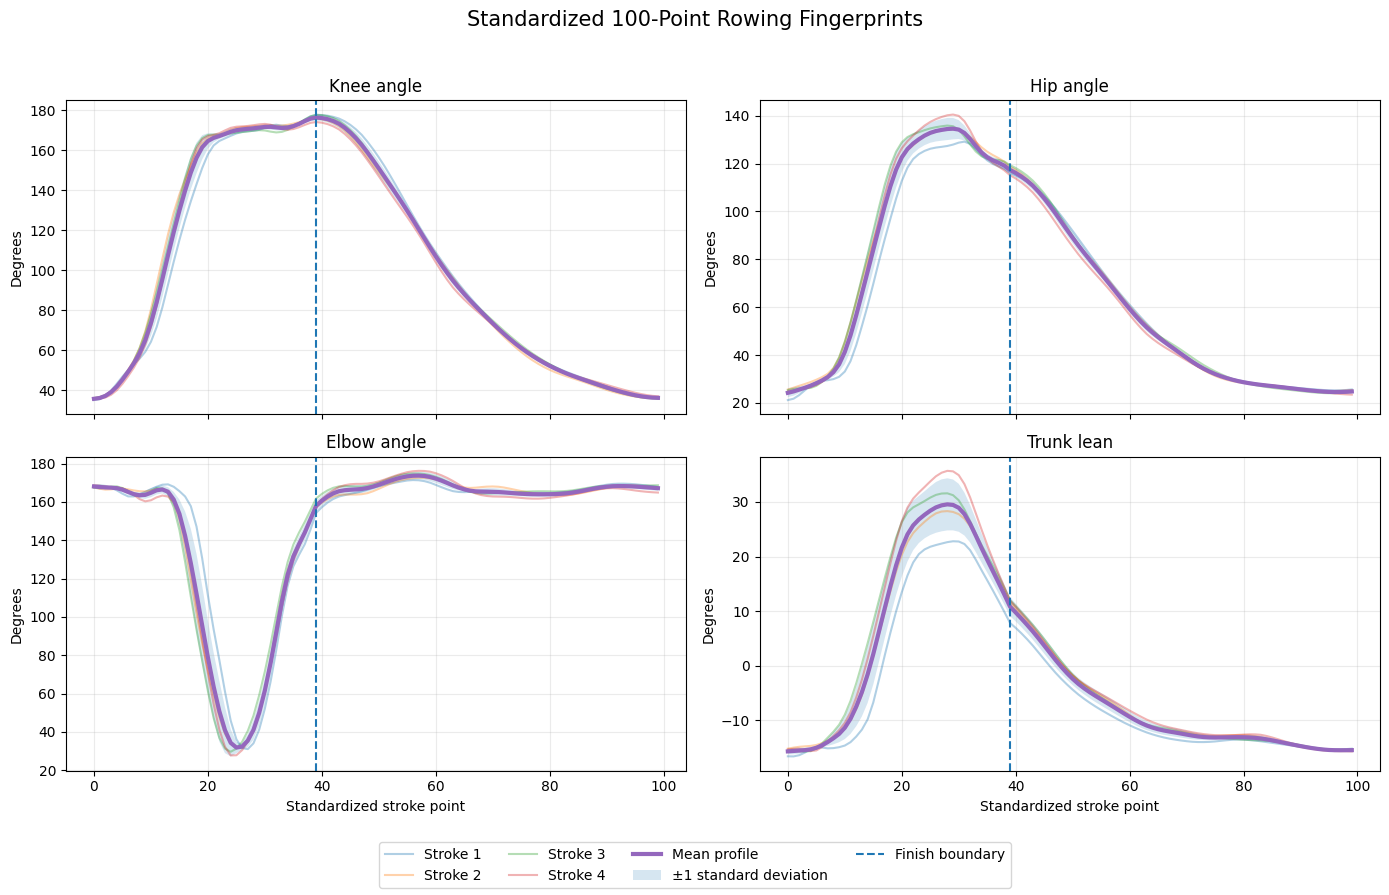

In [ ]:
progress = np.arange(100)
finish_index = 39

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for feature_id, (ax, feature_name) in enumerate(
    zip(axes.ravel(), FEATURE_NAMES)
):
    feature_matrix = standardized_strokes[:, :, feature_id]
    mean_curve = feature_matrix.mean(axis=0)
    std_curve = feature_matrix.std(axis=0)

    for stroke_id, curve in enumerate(feature_matrix, start=1):
        ax.plot(
            progress,
            curve,
            alpha=0.35,
            label=f"Stroke {stroke_id}",
        )

    ax.plot(
        progress,
        mean_curve,
        linewidth=3,
        label="Mean profile",
    )
    ax.fill_between(
        progress,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.18,
        label="±1 standard deviation",
    )
    ax.axvline(
        finish_index,
        linestyle="--",
        linewidth=1.5,
        label="Finish boundary",
    )
    ax.set_title(feature_name)
    ax.set_ylabel("Degrees")
    ax.grid(alpha=0.25)

axes[1, 0].set_xlabel("Standardized stroke point")
axes[1, 1].set_xlabel("Standardized stroke point")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4)
plt.suptitle("Standardized 100-Point Rowing Fingerprints", fontsize=15)
plt.tight_layout(rect=[0, 0.07, 1, 0.96])
plt.show()

# 5. Compare one test stroke with a personal reference

To connect this lesson with KNN and distance, we will:

1. average the earlier strokes into a small reference profile;
2. reserve the final stroke as a test stroke;
3. calculate feature-wise root mean squared error (RMSE).

**Important:** This reference represents consistency within this short video. It is not a coach-validated gold standard.

In [ ]:
if len(standardized_strokes) < 3:
    raise ValueError("At least three complete strokes are required for this demonstration.")

reference_strokes = standardized_strokes[:-1]
test_stroke = standardized_strokes[-1]

reference_mean = reference_strokes.mean(axis=0)
reference_std = reference_strokes.std(axis=0)

rmse_by_feature = np.sqrt(
    np.mean((test_stroke - reference_mean) ** 2, axis=0)
)

comparison_table = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "RMSE_degrees": rmse_by_feature,
}).sort_values("RMSE_degrees", ascending=False)

display(comparison_table.round(2))

,feature,RMSE_degrees
2,Elbow angle,3.79
1,Hip angle,3.38
3,Trunk lean,3.14
0,Knee angle,2.85


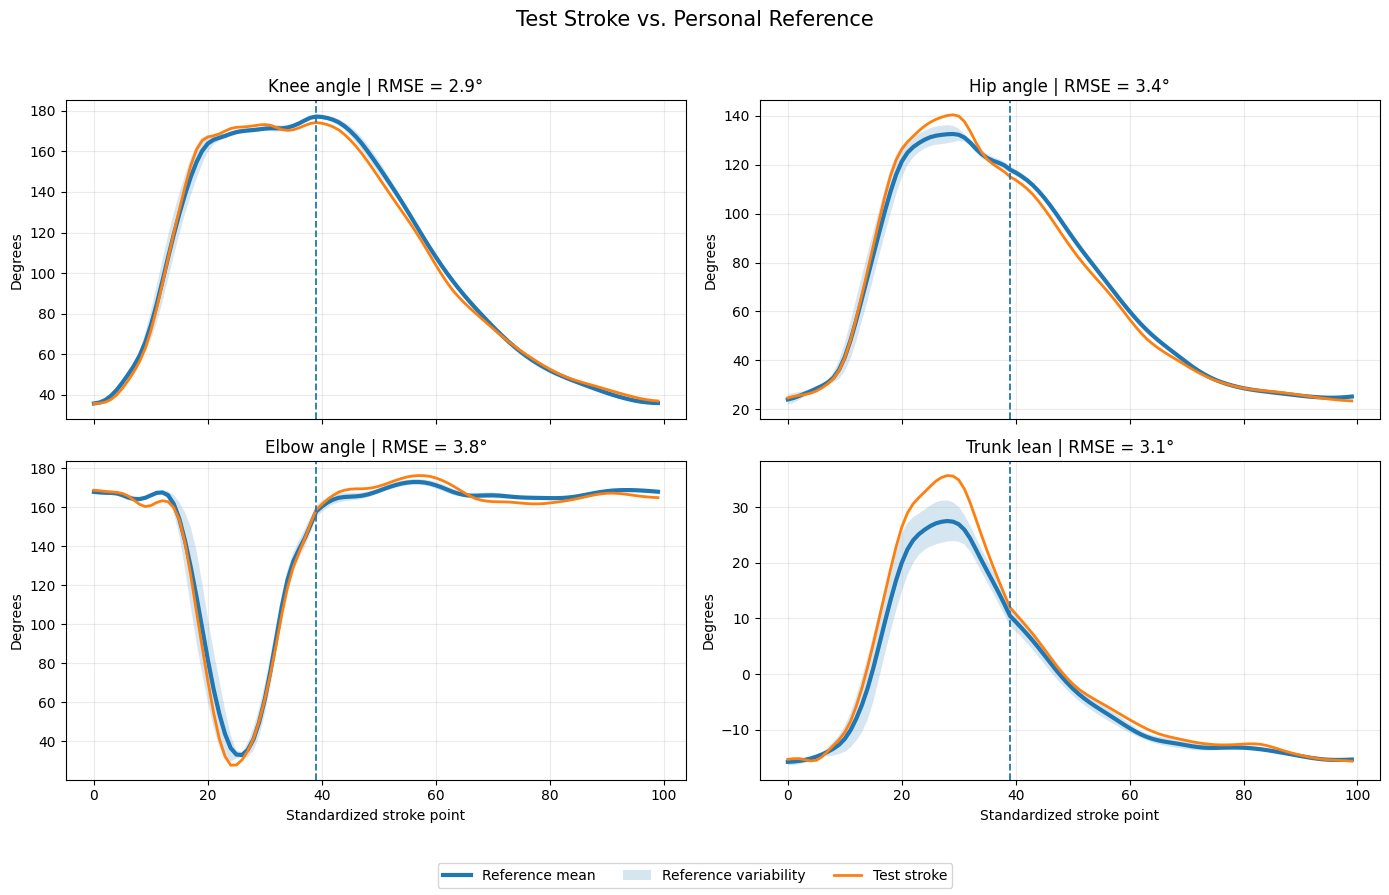

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for feature_id, (ax, feature_name) in enumerate(
    zip(axes.ravel(), FEATURE_NAMES)
):
    mean_curve = reference_mean[:, feature_id]
    std_curve = reference_std[:, feature_id]
    test_curve = test_stroke[:, feature_id]

    ax.plot(
        progress,
        mean_curve,
        linewidth=3,
        label="Reference mean",
    )
    ax.fill_between(
        progress,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.18,
        label="Reference variability",
    )
    ax.plot(
        progress,
        test_curve,
        linewidth=2,
        label="Test stroke",
    )
    ax.axvline(finish_index, linestyle="--", linewidth=1.3)
    ax.set_title(
        f"{feature_name} | RMSE = {rmse_by_feature[feature_id]:.1f}°"
    )
    ax.set_ylabel("Degrees")
    ax.grid(alpha=0.25)

axes[1, 0].set_xlabel("Standardized stroke point")
axes[1, 1].set_xlabel("Standardized stroke point")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)
plt.suptitle("Test Stroke vs. Personal Reference", fontsize=15)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# In-class interpretation

Discuss these questions before reading the homework:

1. Why was knee angle useful for detecting stroke boundaries?
2. Could the same knee angle belong to both Drive and Recovery? How can direction or time resolve the ambiguity?
3. Why did we standardize Drive and Recovery separately?
4. Does a low RMSE prove that the stroke is technically correct?
5. What would happen if the athlete temporarily left the frame?
6. What assumptions would fail if the camera moved?

# Homework — Motion Detection and Standardization Experiment

Complete the following tasks in a copied version of this notebook.

## Part A — Parameter experiment

Test at least **three** combinations of:

- `SMOOTHING_SIGMA`
- `MIN_STROKE_SECONDS`
- `CATCH_PROMINENCE`

Create a table containing:

| Trial | Sigma | Minimum seconds | Prominence | Detected catches | Complete strokes |
|---:|---:|---:|---:|---:|---:|

Explain:

- Which setting over-detects strokes?
- Which setting misses strokes?
- Which setting appears most credible for this video?
- Why should parameters not be chosen only to produce the desired answer?

## Part B — Stroke interpretation

Using the standardized comparison:

1. Identify the feature with the largest RMSE.
2. Identify whether its largest difference occurs during Drive or Recovery.
3. Include one plot supporting your explanation.
4. Write 100–150 words interpreting the result.

## Part C — Scientific limitation

Write 100–150 words answering:

> Why is the mean of a few strokes from one video not a universal definition of safe or ideal rowing technique?

Mention at least three of the following:

- body proportions;
- rowing experience;
- camera placement;
- pose-estimation error;
- fatigue;
- stroke rate;
- coach validation;
- sample size.

## Optional challenge

Extract the horizontal wrist-position signal and calculate wrist velocity:

$$
v_t \approx \frac{x_t-x_{t-1}}{\Delta t}
$$

Compare the wrist-velocity pattern with the knee-angle pattern. What might this reveal about handle timing?

In [ ]:
# Homework starter: test one parameter combination.

def run_detection_experiment(
    raw_knee_signal,
    fps,
    sigma,
    min_stroke_seconds,
    prominence,
):
    smoothed = gaussian_filter1d(raw_knee_signal, sigma=sigma)

    catches, _ = find_peaks(
        -smoothed,
        distance=int(min_stroke_seconds * fps),
        prominence=prominence,
    )

    return {
        "sigma": sigma,
        "minimum_seconds": min_stroke_seconds,
        "prominence": prominence,
        "detected_catches": len(catches),
        "complete_strokes": max(0, len(catches) - 1),
        "catch_frames": catches,
    }


trial = run_detection_experiment(
    raw_knee_signal=motion["knee_angle"].to_numpy(),
    fps=FPS,
    sigma=2.0,
    min_stroke_seconds=2.0,
    prominence=15.0,
)

trial

{'sigma': 2.0,
 'minimum_seconds': 2.0,
 'prominence': 15.0,
 'detected_catches': 5,
 'complete_strokes': 4,
 'catch_frames': array([ 27, 144, 251, 355, 460])}

In [ ]:
# Save the compact outputs for the next lecture.

motion.to_csv("lecture5_motion_features.csv", index=False)

np.savez_compressed(
    "lecture5_standardized_strokes.npz",
    strokes=standardized_strokes,
    reference_mean=reference_mean,
    reference_std=reference_std,
    feature_names=np.array(FEATURE_NAMES),
    finish_index=finish_index,
    fps=FPS,
)

print("Saved:")
print("- lecture5_motion_features.csv")
print("- lecture5_standardized_strokes.npz")

Saved:
- lecture5_motion_features.csv
- lecture5_standardized_strokes.npz


# Exit ticket

Explain the entire lesson in one sentence:

> We converted __________ into __________, detected __________ using __________, and made strokes comparable by __________.

A strong answer should use the terms **time series**, **Catch**, **knee-angle minimum**, and **resampling**.